LinguaCast — Disease Trend Analysis (REAL CDC FluView Data)

Fetching real CDC FluView ILINet national data...
Records retrieved: 711
Usable weeks after cleaning: 711
   epiweek  ili_rate  num_ili  num_patients  week_index  week_of_year
0   201040   1.10939     8473        746485           1            40
1   201041   1.24341     9347        746230           2            41
2   201042   1.25726     9684        777397           3            42
3   201043   1.25734     9904        781234           4            43
4   201044   1.43414    11020        766753           5            44

ILI rate range: 0.53% to 7.52%


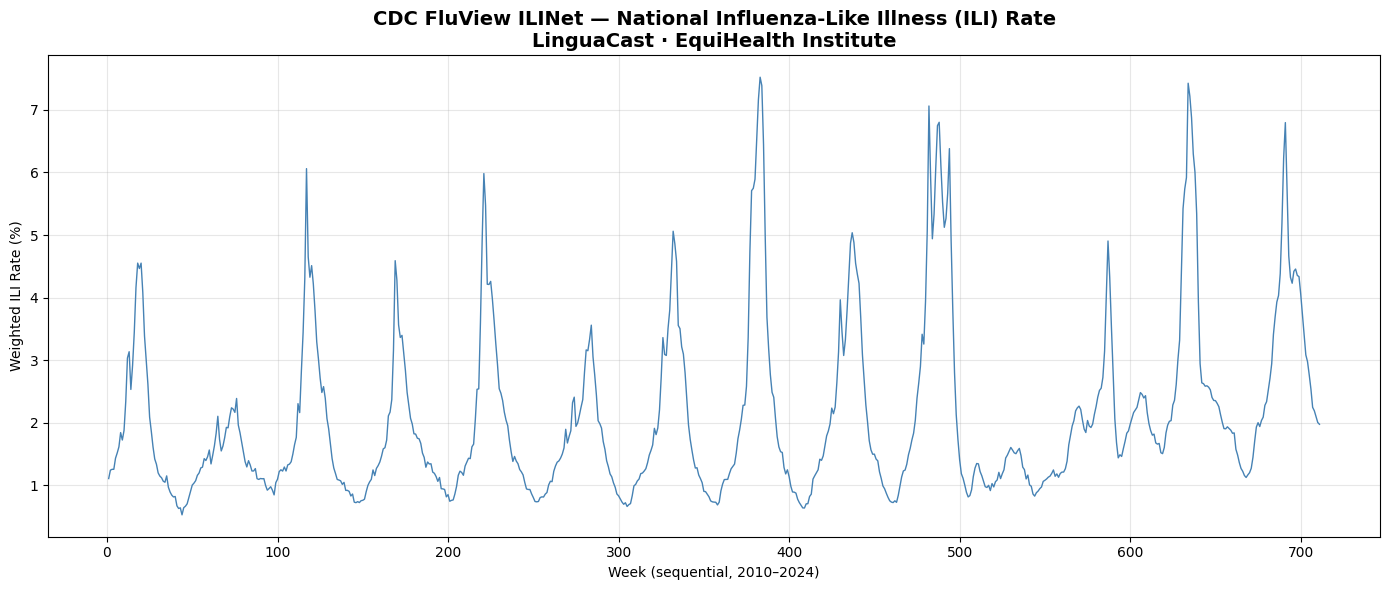

Saved: outputs/real_ili_trend.png

Train weeks: 600  |  Test weeks (unseen): 107

--- OUT-OF-SAMPLE PERFORMANCE ON REAL CDC DATA ---
Linear Regression  R2: 0.9927
Random Forest      R2: 0.9610


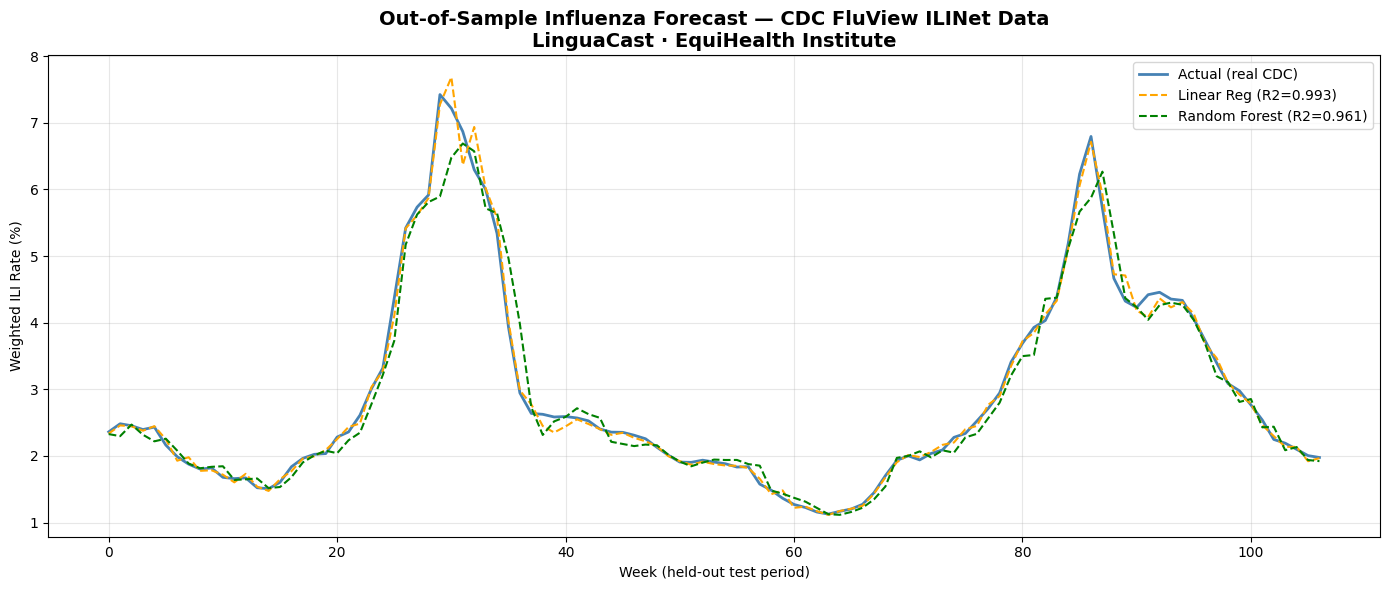

Saved: outputs/real_predictions.png

Latest predicted ILI: 1.92%  ->  Risk: LOW

English: PUBLIC HEALTH ALERT: Influenza activity is LOW. Predicted ILI rate: 1.9%. Take preventive measures.

Spanish: ALERTA DE SALUD PUBLICA: La actividad de influenza es LOW. Tasa estimada de ILI: 1.9%. Tome medidas preventivas.

French: ALERTE DE SANTE PUBLIQUE: L'activite grippale est LOW. Taux d'ILI prevu: 1.9%. Prenez des mesures preventives.

Yoruba: IKILO ILERA: Isele arun imu-je wa ni ipele LOW. Iwon ILI: 1.9%. Jowo mu awon ona idena.

Hausa: GARGADIN LAFIYA: Ayyukan mura yana LOW. Adadin ILI: 1.9%. Da fatan za a dauki matakan kariya.

Swahili: ONYO LA AFYA: Shughuli za mafua ziko LOW. Kiwango cha ILI: 1.9%. Tafadhali chukua hatua za kuzuia.

Saved: outputs/real_multilingual_alerts.txt


LinguaCast — REAL DATA RESULTS SUMMARY
Data Source: CDC FluView ILINet (via Delphi Epidata API, CMU)
Real weeks analyzed: 711
Out-of-sample test weeks: 107

Out-of-Sample Accuracy on REAL data:
  Linear Regressio

In [2]:
# ============================================================
# LinguaCast / EquiHealth Institute
# Disease Trend Analysis — REAL CDC FluView Data Version
# Author: Oluwabusayo Olufunke Awoyomi
# ============================================================
# This version pulls REAL CDC FluView ILINet influenza surveillance
# data via the Delphi Epidata API (Carnegie Mellon University),
# which redistributes official U.S. CDC ILINet data.
# No API key is required for public ILINet data.
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)
print("LinguaCast — Disease Trend Analysis (REAL CDC FluView Data)")
print("="*65)

# ============================================================
# SECTION 1: FETCH REAL CDC FLUVIEW ILINet DATA
# ============================================================
# Delphi Epidata API — national ILINet data
# epiweeks format: YYYYWW (e.g., 201740 = 2017 week 40)
# We pull ~8 seasons of national data.

def fetch_fluview(regions='nat', start='201040', end='202420'):
    url = 'https://api.delphi.cmu.edu/epidata/fluview/'
    params = {'regions': regions, 'epiweeks': f'{start}-{end}'}
    resp = requests.get(url, params=params, timeout=60)
    resp.raise_for_status()
    payload = resp.json()
    if payload.get('result') != 1:
        raise RuntimeError(f"API error: {payload.get('message')}")
    return pd.DataFrame(payload['epidata'])

print("\nFetching real CDC FluView ILINet national data...")
df = fetch_fluview(regions='nat', start='201040', end='202420')
print(f"Records retrieved: {len(df)}")

# The 'wili' column = weighted influenza-like illness percentage (the standard metric)
# Fall back to 'ili' (unweighted) if wili is missing.
df['ili_rate'] = df['wili'].fillna(df['ili'])
df = df[['epiweek', 'ili_rate', 'num_ili', 'num_patients']].copy()
df = df.dropna(subset=['ili_rate']).reset_index(drop=True)

# Build a simple sequential week index and a week-of-year feature
df['week_index'] = range(1, len(df) + 1)
df['week_of_year'] = df['epiweek'].astype(str).str[-2:].astype(int)

print(f"Usable weeks after cleaning: {len(df)}")
print(df.head())
print(f"\nILI rate range: {df['ili_rate'].min():.2f}% to {df['ili_rate'].max():.2f}%")

# ============================================================
# SECTION 2: VISUALIZE THE REAL TREND
# ============================================================
plt.figure(figsize=(14, 6))
plt.plot(df['week_index'], df['ili_rate'], color='steelblue', linewidth=1)
plt.title('CDC FluView ILINet — National Influenza-Like Illness (ILI) Rate\n'
          'LinguaCast · EquiHealth Institute', fontsize=14, fontweight='bold')
plt.xlabel('Week (sequential, 2010–2024)')
plt.ylabel('Weighted ILI Rate (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/real_ili_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/real_ili_trend.png")

# ============================================================
# SECTION 3: FEATURE ENGINEERING
# ============================================================
df['ili_lag1'] = df['ili_rate'].shift(1)
df['ili_lag2'] = df['ili_rate'].shift(2)
df['ili_lag4'] = df['ili_rate'].shift(4)
df['ili_roll4_mean'] = df['ili_rate'].rolling(4).mean()
df['ili_roll4_std']  = df['ili_rate'].rolling(4).std()

df_model = df.dropna().reset_index(drop=True)
features = ['week_of_year', 'ili_lag1', 'ili_lag2', 'ili_lag4',
            'ili_roll4_mean', 'ili_roll4_std']
X = df_model[features]
y = df_model['ili_rate']

# ============================================================
# SECTION 4: HONEST OUT-OF-SAMPLE TEST
# ============================================================
# Train on the earlier ~85%, test on the most recent ~15% the
# model has NEVER seen. This is a true forward-looking test,
# not just fitting the data.
split = int(len(df_model) * 0.85)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"\nTrain weeks: {len(X_train)}  |  Test weeks (unseen): {len(X_test)}")

lr = LinearRegression().fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_r2 = r2_score(y_test, lr_pred)

rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)

print("\n--- OUT-OF-SAMPLE PERFORMANCE ON REAL CDC DATA ---")
print(f"Linear Regression  R2: {lr_r2:.4f}")
print(f"Random Forest      R2: {rf_r2:.4f}")

# ============================================================
# SECTION 5: PLOT ACTUAL vs PREDICTED (REAL, UNSEEN DATA)
# ============================================================
plt.figure(figsize=(14, 6))
plt.plot(range(len(y_test)), y_test.values, label='Actual (real CDC)', color='steelblue', linewidth=2)
plt.plot(range(len(y_test)), lr_pred, '--', label=f'Linear Reg (R2={lr_r2:.3f})', color='orange')
plt.plot(range(len(y_test)), rf_pred, '--', label=f'Random Forest (R2={rf_r2:.3f})', color='green')
plt.title('Out-of-Sample Influenza Forecast — CDC FluView ILINet Data\n'
          'LinguaCast · EquiHealth Institute', fontsize=14, fontweight='bold')
plt.xlabel('Week (held-out test period)')
plt.ylabel('Weighted ILI Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/real_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/real_predictions.png")

# ============================================================
# SECTION 6: RISK CLASSIFICATION + MULTILINGUAL ALERTS
# ============================================================
latest = rf_pred[-1]
risk = "HIGH" if latest > 5 else "MODERATE" if latest > 3 else "LOW"
print(f"\nLatest predicted ILI: {latest:.2f}%  ->  Risk: {risk}")

alerts = {
    "English": f"PUBLIC HEALTH ALERT: Influenza activity is {risk}. Predicted ILI rate: {latest:.1f}%. Take preventive measures.",
    "Spanish": f"ALERTA DE SALUD PUBLICA: La actividad de influenza es {risk}. Tasa estimada de ILI: {latest:.1f}%. Tome medidas preventivas.",
    "French":  f"ALERTE DE SANTE PUBLIQUE: L'activite grippale est {risk}. Taux d'ILI prevu: {latest:.1f}%. Prenez des mesures preventives.",
    "Yoruba":  f"IKILO ILERA: Isele arun imu-je wa ni ipele {risk}. Iwon ILI: {latest:.1f}%. Jowo mu awon ona idena.",
    "Hausa":   f"GARGADIN LAFIYA: Ayyukan mura yana {risk}. Adadin ILI: {latest:.1f}%. Da fatan za a dauki matakan kariya.",
    "Swahili": f"ONYO LA AFYA: Shughuli za mafua ziko {risk}. Kiwango cha ILI: {latest:.1f}%. Tafadhali chukua hatua za kuzuia.",
}
with open('outputs/real_multilingual_alerts.txt', 'w', encoding='utf-8') as f:
    f.write("LinguaCast / EquiHealth Institute — Multilingual Alerts (REAL CDC Data)\n")
    f.write("="*65 + "\n\n")
    for lang, txt in alerts.items():
        print(f"\n{lang}: {txt}")
        f.write(f"{lang}:\n{txt}\n\n")
print("\nSaved: outputs/real_multilingual_alerts.txt")

# ============================================================
# SECTION 7: SUMMARY
# ============================================================
print("\n" + "="*65)
print(f"""
LinguaCast — REAL DATA RESULTS SUMMARY
Data Source: CDC FluView ILINet (via Delphi Epidata API, CMU)
Real weeks analyzed: {len(df)}
Out-of-sample test weeks: {len(X_test)}

Out-of-Sample Accuracy on REAL data:
  Linear Regression R2: {lr_r2:.4f}
  Random Forest     R2: {rf_r2:.4f}

Current predicted ILI: {latest:.2f}%  |  Risk: {risk}
Alerts generated in: English, Spanish, French, Yoruba, Hausa, Swahili
""")